In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset,DataLoader
from torchvision import transforms

from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from Crypto.Util import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
DATASET_PATH=r"C:\Users\Yashraj Singh\OneDrive\Desktop\archive\seg_train\seg_train"

IMAGE_SIZE=150

BATCH_SIZE=64

EPOCHS=10

LEARNING_RATE=0.001

AES_KEY=b"1234567890ABCDEF"

In [3]:
image_paths=[]

for root,dirs,files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".jpg"):

            image_paths.append(
                os.path.join(
                    root,
                    file
                )
            )

print("Images =",len(image_paths))

Images = 14034


In [4]:
print("Using Images =",len(image_paths))

Using Images = 14034


In [5]:
def encrypt_ctr(image_array):

    image_bytes=image_array.tobytes()

    ctr=Counter.new(128)

    cipher=AES.new(
        AES_KEY,
        AES.MODE_CTR,
        counter=ctr
    )

    encrypted=cipher.encrypt(
        image_bytes
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted

In [6]:
def encrypt_cbc(image_array):

    image_bytes=image_array.tobytes()

    iv=b"1234567890ABCDEF"

    cipher=AES.new(
        AES_KEY,
        AES.MODE_CBC,
        iv
    )

    encrypted=cipher.encrypt(
        pad(
            image_bytes,
            AES.block_size
        )
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted

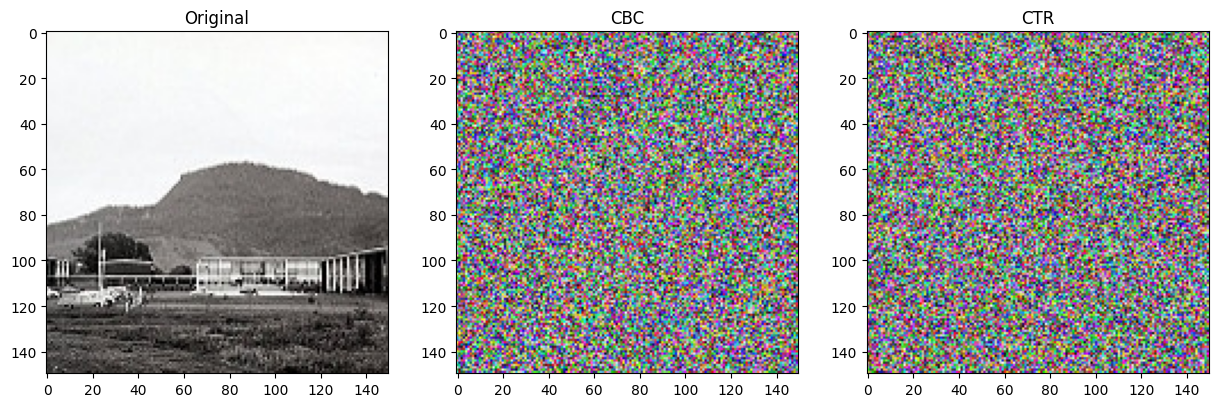

In [7]:
img=np.array(
    Image.open(
        image_paths[0]
    ).resize(
        (IMAGE_SIZE,IMAGE_SIZE)
    )
)

cbc=encrypt_cbc(img)

ctr=encrypt_ctr(img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cbc)
plt.title("CBC")

plt.subplot(1,3,3)
plt.imshow(ctr)
plt.title("CTR")

plt.show()

In [8]:
train_paths,val_paths=train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_paths))
print(len(val_paths))

11227
2807


In [9]:
class AESDataset(Dataset):

    def __init__(
        self,
        image_paths
    ):

        self.image_paths=image_paths

        self.transform=transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10)
        ])

    def __len__(self):

        return len(self.image_paths)*2

    def __getitem__(self,index):

        image_index=index//2

        class_label=index%2

        path=self.image_paths[
            image_index
        ]

        img=Image.open(path)

        img=img.convert("RGB")

        img=img.resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )

        img=self.transform(img)

        img=np.array(img)

        if class_label==0:

            img=encrypt_cbc(img)

        else:

            img=encrypt_ctr(img)

        img=img.astype(np.float32)

        img=img/255.0

        img=torch.tensor(
            img,
            dtype=torch.float32
        )

        img=img.permute(
            2,
            0,
            1
        )

        return img,class_label

In [10]:
train_dataset=AESDataset(
    train_paths
)

val_dataset=AESDataset(
    val_paths
)

print(len(train_dataset))
print(len(val_dataset))

22454
5614


In [11]:
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders Created")

DataLoaders Created


In [12]:
images,labels=next(
    iter(train_loader)
)

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 150, 150])
torch.Size([64])


In [13]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features=nn.Sequential(

            nn.Conv2d(
                3,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier=nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256*9*9,
                512
            ),

            nn.ReLU(),

            nn.Linear(
                512,
                2
            )
        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [14]:
model=CNN().to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(
    next(
        model.parameters()
    ).device
)

cuda:0


In [15]:
train_losses=[]
val_losses=[]

print("Starting Training")

for epoch in range(EPOCHS):

    model.train()

    train_loss=0

    for images,labels in train_loader:

        images=images.to(device)

        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    train_losses.append(
        train_loss
    )

    model.eval()

    val_loss=0

    correct=0

    total=0

    with torch.no_grad():

        for images,labels in val_loader:

            images=images.to(device)

            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(
                outputs,
                labels
            )

            val_loss+=loss.item()

            _,predicted=torch.max(
                outputs,
                1
            )

            total+=labels.size(0)

            correct+=(
                predicted==labels
            ).sum().item()

    val_loss/=len(val_loader)

    val_losses.append(
        val_loss
    )

    accuracy=100*correct/total

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Train Loss:{train_loss:.4f} "
        f"Val Loss:{val_loss:.4f} "
        f"Val Accuracy:{accuracy:.2f}%"
    )

Starting Training
Epoch 1/10 Train Loss:0.1842 Val Loss:0.0079 Val Accuracy:99.75%
Epoch 2/10 Train Loss:0.0031 Val Loss:0.0013 Val Accuracy:99.96%
Epoch 3/10 Train Loss:0.0443 Val Loss:0.0049 Val Accuracy:99.84%
Epoch 4/10 Train Loss:0.0032 Val Loss:0.0012 Val Accuracy:100.00%
Epoch 5/10 Train Loss:0.0044 Val Loss:0.0014 Val Accuracy:99.95%
Epoch 6/10 Train Loss:0.0016 Val Loss:0.0032 Val Accuracy:99.88%
Epoch 7/10 Train Loss:0.0017 Val Loss:0.0015 Val Accuracy:99.96%
Epoch 8/10 Train Loss:0.0012 Val Loss:0.0052 Val Accuracy:99.79%
Epoch 9/10 Train Loss:0.0013 Val Loss:0.0039 Val Accuracy:99.89%
Epoch 10/10 Train Loss:0.0014 Val Loss:0.0012 Val Accuracy:99.96%


In [16]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        outputs=model(images)

        _,preds=torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm=confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "CBC",
            "CTR"
        ]
    )
)

[[2807    0]
 [   2 2805]]
              precision    recall  f1-score   support

         CBC       1.00      1.00      1.00      2807
         CTR       1.00      1.00      1.00      2807

    accuracy                           1.00      5614
   macro avg       1.00      1.00      1.00      5614
weighted avg       1.00      1.00      1.00      5614



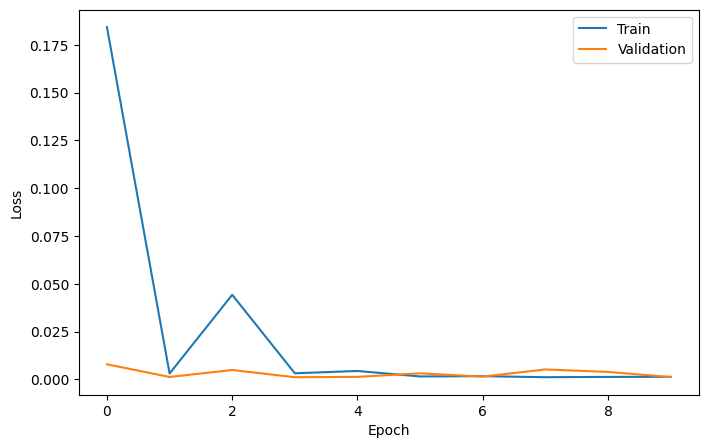

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "intel_aes_classifier.pth"
)